In [1]:
import numpy as np
import h5py
import illustris_python as il
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

In [2]:
basePath       = '../sims.TNG/TNG50-3/output/'
snapshot_num   = 59          # alterar para z = 0, z = 0.5 ou z = 0.7
zred           = 0.7
afactor        = 1.0 / (1 + zred)

radius_cut     = 300.0       # raio máximo de análise (kpc/h)
icl_limit      = 5           # múltiplo do R_half para definir ICL                  

radii_bins     = np.arange(0, radius_cut + 10, 10)
# bins de 10 kpc/h
radius_centers = (radii_bins[1:] + radii_bins[:-1]) / 2.0

# Idade do universo
from astropy.cosmology import Planck15
import astropy.units as u
age_universe_gyr = Planck15.age(zred).to(u.Gyr).value
age_universe_gyr

7.310025232604206

In [3]:
halos = il.groupcat.loadHalos(basePath, snapshot_num,
    fields=['GroupFirstSub', 'Group_M_Mean200', 'GroupPos', 'Group_R_Mean200'])

subhalos = il.groupcat.loadSubhalos(basePath, snapshot_num,
    fields=['SubhaloFlag', 'SubhaloPos', 'SubhaloHalfmassRad',
            'SubhaloMass', 'SubhaloStellarPhotometrics'])

stars = il.snapshot.loadSubset(basePath, snapshot_num, 'stars',
    fields=['Coordinates', 'Velocities', 'Masses',
            'GFM_Metallicity', 'GFM_StellarFormationTime'])

In [4]:
# SELECIONAR HALOS MASSIVOS
# Group_M_Mean200 > 5e3 

ind, = np.where(halos['Group_M_Mean200'] > 5.0e3)
print(f"Halos selecionados: {len(ind)}")
print(f"log10(M200) = {np.log10(halos['Group_M_Mean200'][ind]) + 10.0}")

Halos selecionados: 1
log10(M200) = [13.8532295]


In [5]:
def estimate_recent_sfr(masses, formation_time_scalefactor, age_universe_gyr, young_limit_gyr=0.1):
    
    h = 0.6774

    # Filtrar partículas de vento 
    valid = formation_time_scalefactor > 0
    
    sfr = np.zeros(len(masses))

    if np.sum(valid) == 0:
        return sfr
    
    # criando uma lista sem zeros falsos
    age_gyr = np.full(len(masses), np.nan)

    # a -> z_form
    a_form = formation_time_scalefactor[valid]
    z_form = (1.0 / a_form) - 1.0

    # tempo cosmológico de formação, garantindo que vai estar em Gyr
    t_form = Planck15.age(z_form).to(u.Gyr).value

    # idade estelar correta
    stellar_age = age_universe_gyr - t_form
    
    #selecionando estrelas jovens
    young = stellar_age < young_limit_gyr

    # convertendo a massa
    masses_msun = masses[valid] * 1e10 / h
    
    # calculando SFR
    sfr_valid = np.zeros(len(masses_msun))
    sfr_valid[young] = masses_msun[young] / (young_limit_gyr * 1e9)

    sfr[valid] = sfr_valid

    return sfr

In [6]:
# LOOP PRINCIPAL: POR HALO

all_sfr_icl     = []
all_dist_icl   = []
all_mass_icl   = []

all_sfr_noicl   = []
all_dist_noicl = []
all_mass_noicl = []

for i in ind[:1]:

    print(f"\n--- Processando halo {i} ---")
    halo_cent = halos['GroupPos'][i, :]


    # Distância dos subhalos ao centro do halo

    subhalo_dist = np.sqrt(
        (subhalos['SubhaloPos'][:, 0] - halo_cent[0])**2 +
        (subhalos['SubhaloPos'][:, 1] - halo_cent[1])**2 +
        (subhalos['SubhaloPos'][:, 2] - halo_cent[2])**2)
    subhalo_dist_ind, = np.where(subhalo_dist < radius_cut + 100)


    # Distância das estrelas ao centro do halo

    dist_stars = np.sqrt(
        (stars['Coordinates'][:, 0] - halo_cent[0])**2 +
        (stars['Coordinates'][:, 1] - halo_cent[1])**2 +
        (stars['Coordinates'][:, 2] - halo_cent[2])**2)
    
    # Selecionar estrelas dentro do raio de análise
    dist_ind, = np.where((dist_stars < radius_cut) & (dist_stars > 5))
    print(f"  Estrelas no raio de análise: {len(dist_ind)}")

    # Calcular cor g-r para cada partícula estelar
    
    sfr_all = estimate_recent_sfr(
        stars['Masses'][dist_ind],
        stars['GFM_StellarFormationTime'][dist_ind],
        age_universe_gyr)

    # Separação ICL vs não-ICL
    # Inicializa: todas as estrelas como ICL (flag = 1)
    subhalo_star_distance_norm = np.ones(len(dist_ind))

    # Para cada subhalo próximo (exceto o primeiro = halo principal)
    for jj in subhalo_dist_ind[1:]:
        subhalo_x = subhalos['SubhaloPos'][jj, 0]
        subhalo_y = subhalos['SubhaloPos'][jj, 1]
        subhalo_z = subhalos['SubhaloPos'][jj, 2]
        r_half    = subhalos['SubhaloHalfmassRad'][jj]

        if r_half <= 0:
            continue

        # Distância de cada estrela a este subhalo, normalizada por N*R_half
        d = np.sqrt(
            (stars['Coordinates'][dist_ind, 0] - subhalo_x)**2 +
            (stars['Coordinates'][dist_ind, 1] - subhalo_y)**2 +
            (stars['Coordinates'][dist_ind, 2] - subhalo_z)**2
        ) / (r_half * icl_limit)

        # Estrelas dentro do raio → pertencem ao subhalo (não-ICL)
        inside, = np.where(d < 1.0)
        subhalo_star_distance_norm[inside] = 0

    # ICL: estrelas que NÃO pertencem a nenhum subhalo
    ind_icl,    = np.where(subhalo_star_distance_norm > 0.5)
    ind_no_icl, = np.where(subhalo_star_distance_norm < 0.5)

    print(f"  Estrelas ICL:     {len(ind_icl)}")
    print(f"  Estrelas não-ICL: {len(ind_no_icl)}")

    #  Guardar distâncias, cores e massas para o plot
    
    # ICL
    all_dist_icl.append(dist_stars[dist_ind[ind_icl]])
    all_sfr_icl.append(sfr_all[ind_icl])
    all_mass_icl.append(stars['Masses'][dist_ind[ind_icl]])

    # não-ICL
    all_dist_noicl.append(dist_stars[dist_ind[ind_no_icl]])
    all_sfr_noicl.append(sfr_all[ind_no_icl])
    all_mass_noicl.append(stars['Masses'][dist_ind[ind_no_icl]])


--- Processando halo 0 ---
  Estrelas no raio de análise: 172803
  Estrelas ICL:     66505
  Estrelas não-ICL: 106298


In [7]:
# CONCATENAR (no caso de múltiplos halos)

dist_icl   = np.concatenate(all_dist_icl)
sfr_icl     = np.concatenate(all_sfr_icl)
mass_icl   = np.concatenate(all_mass_icl)

dist_noicl = np.concatenate(all_dist_noicl)
sfr_noicl   = np.concatenate(all_sfr_noicl)
mass_noicl = np.concatenate(all_mass_noicl)

In [8]:
# BINAGEM RADIAL: média ponderada pela massa

def radial_sfr_profile(dist, sfr, bins):

    """ Calcula perfil radial de SFR """
    
    bin_sfr   = np.full(len(bins) - 1, np.nan)
    bin_std    = np.full(len(bins) - 1, np.nan)
    bin_center = (bins[1:] + bins[:-1]) / 2.0

    for k in range(len(bins) - 1):
        mask = (dist >= bins[k]) & (dist < bins[k+1])
        
        if mask.sum() < 5:  # mínimo de 5 partículas por bin
            continue
            
        sfr_bin = sfr[mask]

        # SFR total no bin
        bin_sfr[k] = np.sum(sfr_bin)

        # dispersão
        bin_std[k] = np.std(sfr_bin)

    return bin_center, bin_sfr, bin_std

print("\nCalculando perfis radiais de SFR...")

r_icl, sfr_profile_icl, sfr_std_icl = radial_sfr_profile(
    dist_icl, sfr_icl, radii_bins)

r_noicl, sfr_profile_noicl, sfr_std_noicl = radial_sfr_profile(
    dist_noicl, sfr_noicl, radii_bins)


Calculando perfis radiais de SFR...



Gráfico salvo.


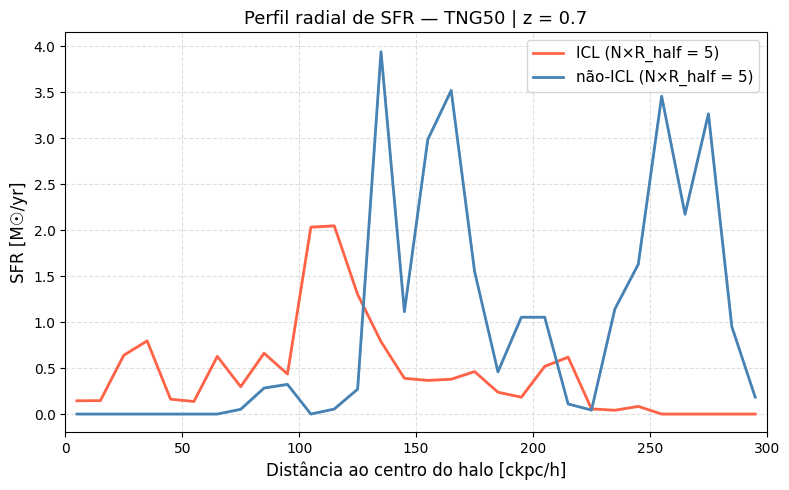

In [9]:
# PLOT

fig, ax = plt.subplots(figsize=(8, 5))

# ICL
mask_icl = np.isfinite(sfr_profile_icl)

ax.plot(r_icl[mask_icl], sfr_profile_icl[mask_icl], color='tomato', lw=2, label=f'ICL (N×R_half = {icl_limit})')

ax.fill_between(r_icl[mask_icl], sfr_profile_icl[mask_icl] - sfr_std_icl[mask_icl],
                sfr_profile_icl[mask_icl] + sfr_std_icl[mask_icl], color='tomato', alpha=0.2)

# não-ICL
mask_noicl = np.isfinite(sfr_profile_noicl)

ax.plot(r_noicl[mask_noicl], sfr_profile_noicl[mask_noicl], color='steelblue', lw=2,
        label=f'não-ICL (N×R_half = {icl_limit})')
ax.fill_between(r_noicl[mask_noicl], sfr_profile_noicl[mask_noicl] - sfr_std_noicl[mask_noicl],
                sfr_profile_noicl[mask_noicl] + sfr_std_noicl[mask_noicl], color='steelblue', alpha=0.2)

ax.set_xlabel('Distância ao centro do halo [ckpc/h]', fontsize=12)
ax.set_ylabel('SFR [M☉/yr]', fontsize=12)
ax.set_title(f'Perfil radial de SFR — TNG50 | z = {zred}', fontsize=13)
ax.set_xlim(0, radius_cut)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'sfr_profile_icl_limit{icl_limit}_z{zred}.png',dpi=150)

print("\nGráfico salvo.")

plt.show()